# 1. Notebook kernel setup

After cloning repository at https://github.com/EstebanRivera08/PyCalib, and the uv package, go on terminal to the location of the repository and run the following command to install the required packages:

`` uv run pycalib ``

To run these jupyter notebooks, the .venv environment of the project must be used as kernel.
To do so, from the repository path, you can run.

`` uv run -m ipykernel install --user --name=.venv --display-name "PySonoGen (.venv)" ``

This will create a jupyter kernel named 'PySonoGen (.venv)', that one can then select as kernel
of the notebook.


In [1]:
!where python

c:\Users\deyve\Documents\PySonoGen\.venv\Scripts\python.exe
C:\Users\deyve\AppData\Local\Microsoft\WindowsApps\python.exe


# 2. BrainGlobe

In [2]:
from brainglobe_atlasapi import BrainGlobeAtlas
from brainglobe_atlasapi import show_atlases
from pprint import pprint

import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

## 2.1. Check atlas disponibilites

In [3]:
show_atlases()

╭───────────────────────────────── Brainglobe Atlases ─────────────────────────────────╮
│                                                                           Latest     │
│  Name                              Downloaded  Updated  Local version    version     │
│  allen_mouse_25um                      ✔          ✔          1.2           1.2       │
│  whs_sd_rat_39um                       ✔          ✔          1.2           1.2       │
│  admba_3d_e11_5_mouse_16um                                                 1.1       │
│  admba_3d_e13_5_mouse_16um                                                 1.1       │
│  admba_3d_e15_5_mouse_16um                                                 1.1       │
│  admba_3d_e18_5_mouse_16um                                                 1.1       │
│  admba_3d_p14_mouse_16.752um                                               1.1       │
│  admba_3d_p28_mouse_16.752um                                               1.1       │
│  admba_3d_p4_mouse_16.752um                                                1.1       │
│  admba_3d_p56_mouse_25um                                                   1.1       │
│  allen_cord_20um                                                           1.1       │
│  allen_human_500um                                                         1.0       │
│  allen_mouse_100um                                                         1.2       │
│  allen_mouse_10um                                                          1.2       │
│  allen_mouse_50um                                                          1.2       │
│  allen_mouse_bluebrain_barrels_1…                                          1.0       │
│  allen_mouse_bluebrain_barrels_2…                                          1.0       │
│  australian_mouse_15um                                                     1.0       │
│  azba_zfish_4um                                                            1.2       │
│  columbia_cuttlefish_50um                                                  1.0       │
│  csl_cat_500um                                                             1.0       │
│  eurasian_blackcap_25um                                                    1.2       │
│  example_mouse_100um                                                       1.2       │
│  kim_dev_mouse_e11-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e11-5_mri-adc_31.…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-dwi_31.…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-fa_31.5…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-t2_31.5…                                          1.3       │
│  kim_dev_mouse_e13-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e13-5_mri-adc_34um                                          1.3       │
│  kim_dev_mouse_e13-5_mri-dwi_34um                                          1.3       │
│  kim_dev_mouse_e13-5_mri-fa_34um                                           1.3       │
│  kim_dev_mouse_e13-5_mri-t2_34um                                           1.3       │
│  kim_dev_mouse_e15-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e15-5_mri-adc_37.…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-dwi_37.…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-fa_37.5…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-mtr_37.…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-t2_37.5…                                          1.3       │
│  kim_dev_mouse_e18-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e18-5_mri-adc_40um                                          1.3       │
│  kim_dev_mouse_e18-5_mri-dwi_40um                                          1.3    

## 2.2. Select an atlas

Let's select one (if atlas is not previously downloaded, one needs internet to download it):

In [4]:
bg_atlas = BrainGlobeAtlas("whs_sd_rat_39um", check_latest=False)

### 2.2.1. Metadata

All atlases have a standard set of metatata describing their source, species, resolution, etc

In [5]:
bg_atlas.metadata

{'name': 'whs_sd_rat',
 'citation': 'Kleven et al 2023, https://doi.org/10.1038/s41592-023-02034-3',
 'atlas_link': 'https://www.nitrc.org/projects/whs-sd-atlas',
 'species': 'Rattus norvegicus',
 'symmetric': False,
 'resolution': [39.0, 39.0, 39.0],
 'orientation': 'asr',
 'version': '1.2',
 'shape': [1024, 512, 512],
 'trasform_to_bg': [[0.0, -1.0, 0.0, 39936.0],
  [0.0, 0.0, -1.0, 19968.0],
  [-1.0, 0.0, 0.0, 19968.0],
  [0.0, 0.0, 0.0, 1.0]],
 'additional_references': [],
 'atlas_packager': 'Harry Carey, University of Oslo, Norway, harry.carey@medisin.uio.no'}

### 2.2.2. Type of information

Other information:

In [6]:
annatomical_ref_stack = bg_atlas.reference

In [7]:
annotations_stack = bg_atlas.annotation

In [8]:
hemispheres_stack = bg_atlas.hemispheres

### 2.2.3. Regions hierarchy:

The atlas comes with the description of a hierarchy of brain structures. To have an overview:

``` bg_atlas.structures ```

The structures attribute is a custom dictionary that can be queried by region number or acronym, and contains all the information for a given structure

In [9]:
bg_atlas.structures

root (10000)
├── Brain (1000)
│   ├── GM (1013)
│   │   ├── Dien (1080)
│   │   │   ├── HY (1034)
│   │   │   │   └── HTh-u (48)
│   │   │   ├── PreT (1096)
│   │   │   │   ├── PRT (94)
│   │   │   │   └── Sag (163)
│   │   │   ├── Thal-D (1084)
│   │   │   │   ├── ANT (1085)
│   │   │   │   │   ├── AD (213)
│   │   │   │   │   ├── AM (254)
│   │   │   │   │   ├── AV (1086)
│   │   │   │   │   │   ├── AV-dm (214)
│   │   │   │   │   │   └── AV-vl (215)
│   │   │   │   │   ├── IAM (255)
│   │   │   │   │   ├── IMD (260)
│   │   │   │   │   ├── PIL (208)
│   │   │   │   │   ├── PT (211)
│   │   │   │   │   ├── PV (242)
│   │   │   │   │   └── SPF (278)
│   │   │   │   ├── ILM (1092)
│   │   │   │   │   ├── CL (248)
│   │   │   │   │   ├── CM (247)
│   │   │   │   │   ├── Eth (282)
│   │   │   │   │   ├── PCN (246)
│   │   │   │   │   └── PF (267)
│   │   │   │   ├── LD (1095)
│   │   │   │   │   ├── DLG (205)
│   │   │   │   │   ├── LD-dm (228)
│   │   │   │   │   └── LD-vl (229)
│   │  

In [10]:
id_motorarea = bg_atlas.structures['MO']["id"]
print(bg_atlas.structures['MO'].keys())

KeysView({'name': 'Medial orbital area', 'acronym': 'MO', 'id': 403, 'structure_id_path': [10000, 1000, 1013, 1052, 1053, 1015, 1061, 1062, 403], 'rgb_triplet': [63, 72, 204], 'mesh_filename': WindowsPath('C:/Users/deyve/.brainglobe/whs_sd_rat_39um_v1.2/meshes/403.obj'), 'mesh': None})


In [11]:
for id_region, region in bg_atlas.structures.items():  
     # Check if the structure has no parent (or parent is the root)
        print(f"{id_region}: {region['name'], region['acronym']}")

10000: ('Root', 'root')
1000: ('Brain', 'Brain')
1001: ('White matter', 'wmt')
1050: ('Olfactory white matter', 'olf')
180: ('lateral olfactory tract', 'lot')
67: ('corpus callosum and associated subcortical white matter', 'cc-ec-cing-dwm')
1002: ('Anterior commissure', 'ac')
36: ('anterior commissure, anterior limb', 'aca')
37: ('anterior commissure, posterior limb', 'acp')
73: ('anterior commissure, intrabulbar part', 'aci')
1003: ('Hippocampal white matter', 'hiw')
6: ('alveus of the hippocampus', 'alv')
38: ('ventral hippocampal commissure', 'vhc')
52: ('fornix', 'f')
59: ('fimbria of the hippocampus', 'fi')
1004: ('Corticofugal pathways', 'cfp')
1: ('corticofugal tract and corona radiata', 'ic-cp-lfp-py')
85: ('pyramidal decussation', 'pyx')
1005: ('Medial lemniscus', 'ml')
34: ('medial lemniscus, unspecified', 'ml-u')
84: ('medial lemniscus decussation', 'mlx')
1006: ('Thalamic tracts', 'tht')
1051: ('External medullary lamina', 'eml')
249: ('external medullary lamina, unspecifie

In [12]:
for id_region, region in bg_atlas.structures.items():  
     # Check if the structure has no parent (or parent is the root)
    if any(id == id_motorarea for id in region["structure_id_path"]):
        print(f"{id_region}: {region['name'], region['acronym']}")

403: ('Medial orbital area', 'MO')


# 3. 3D visualization of the brain

Let's plot a 3D visualization with of the selected atlas.

To do so, we create a function that converts the atlas'mesh to a pyvista object.

In [13]:
def meshio_to_pv(
    mesh_io,
    *,
    translation=None,
    rotate_x=0,
    rotate_y=0,
    rotate_z=0,
    order = "xyz",
    flip_z=False,
    scaling_factor=1e-3,  # μm → mm conversion 
):  
    """Convert meshio.Mesh → pyvista.PolyData with transformations."""
    verts = mesh_io.points.copy()  # Work on a copy to preserve original data
    tris = mesh_io.cells_dict.get("triangle", [])

    if len(tris) == 0:
        return None
    
    # 1. Convert to millimeters first
    verts *= scaling_factor
    
    # Create temporary PolyData for transformations
    polydata = pv.PolyData(
        verts,
        np.hstack([np.full((tris.shape[0], 1), 3, dtype=int), tris]).ravel()
    )
    
    # 2. Rotations (order matters: X → Y → Z)
    if order == "xyz":
        polydata.rotate_x(rotate_x, inplace=True)
        polydata.rotate_y(rotate_y, inplace=True)
        polydata.rotate_z(rotate_z, inplace=True)
    elif order == "zyx":
        polydata.rotate_z(rotate_z, inplace=True)
        polydata.rotate_y(rotate_y, inplace=True)
        polydata.rotate_x(rotate_x, inplace=True)
    elif order == "xzy":
        polydata.rotate_x(rotate_x, inplace=True)
        polydata.rotate_z(rotate_z, inplace=True)
        polydata.rotate_y(rotate_y, inplace=True)
    elif order == "yxz":
        polydata.rotate_y(rotate_y, inplace=True)
        polydata.rotate_x(rotate_x, inplace=True)
        polydata.rotate_z(rotate_z, inplace=True)
    elif order == "yzx":
        polydata.rotate_y(rotate_y, inplace=True)
        polydata.rotate_z(rotate_z, inplace=True)
        polydata.rotate_x(rotate_x, inplace=True)
    elif order == "zxy":
        polydata.rotate_z(rotate_z, inplace=True)
        polydata.rotate_x(rotate_x, inplace=True)
        polydata.rotate_y(rotate_y, inplace=True)
    else:
        raise ValueError(f"Invalid order: {order}. Use 'xyz', 'zyx', 'xzy', 'yxz', 'yzx', or 'zxy'.")

    # # 3. re-center
    if translation is not None:
        polydata.translate(translation, inplace=True)

    return polydata

Let's suppose we have not created the atlas object

In [14]:
# 2. Grab the full‐brain mesh (the “root” structure) and your region mesh
#    mesh_from_structure returns a meshio object with .points and .cells_dict["triangle"]
region_name   = "M1" #"MOp"  # the region you want to visualize :contentReference[oaicite:0]{index=0}
full_mesh_io   = bg_atlas.mesh_from_structure("root")  # the entire brain surface :contentReference[oaicite:0]{index=0}
region_id      = bg_atlas.structures[region_name]["id"]     # get the numeric ID for VISp
region_mesh_io = bg_atlas.mesh_from_structure(region_id)

region_name2   = "S1-hl"  #"SSp-ll"  # the region you want to visualize :contentReference[oaicite:0]{index=0}
region_id2      = bg_atlas.structures[region_name2]["id"]     # get the numeric ID for VISp
region_mesh_io2 = bg_atlas.mesh_from_structure(region_id2)

# 3. Prepare transformations on the mesh if needed
#    (e.g., center the mesh, rotate it, etc.)
# We will use the full-brain mesh to center and rotate the region mesh
rotate_x = 0  # rotate the mesh around the x-axis
rotate_y = -90 # rotate the mesh around the y-axis
rotate_z = -90  # rotate the mesh around the z-axis
order = "zyx"  # rotation order
pv_brain_ref = meshio_to_pv(full_mesh_io, rotate_x=rotate_x, rotate_y=rotate_y, rotate_z=rotate_z, order=order)
current_center = np.array(pv_brain_ref.center)  # current center of the mesh (in mm)
center = (0, 0, 0)  # center of the mesh (in mm)
translation = -current_center + np.array(center)  # center the mesh at the center of the whole brain
# translation = None

# 4. And we apply the transformations to the mesh
pv_brain = meshio_to_pv(full_mesh_io, translation=translation, rotate_x=rotate_x, rotate_y=rotate_y, rotate_z=rotate_z, order=order)
pv_region = meshio_to_pv(region_mesh_io, translation=translation, rotate_x=rotate_x, rotate_y=rotate_y, rotate_z=rotate_z, order=order)
pv_region2 = meshio_to_pv(region_mesh_io2, translation=translation, rotate_x=rotate_x, rotate_y=rotate_y, rotate_z=rotate_z, order=order)

In [15]:
# 3. Plot in a standalone Qt window
plotter = pv.Plotter(window_size=[1024, 768], title=f"Atlas + {region_name}", notebook=False)
plotter.add_mesh(pv_brain,   color="lightgrey", opacity=0.2,    label="brain")
plotter.add_mesh(pv_region,  color="tomato",     opacity=0.6,    label=region_name)
plotter.add_mesh(pv_region2,  color="blue",     opacity=0.6,    label=region_name2)
plotter.add_axes()              # show XYZ axes
plotter.show_grid()             # show grid
plotter.add_legend(loc = 'upper left')             # show legend
plotter.camera.up = (0,0, -1)  # set the camera up vector to Z axis
zoom = 5  # zoom factor
plotter.camera.position = (12*zoom, 12*zoom, -10*zoom)  # set the camera position

plotter.show()  # Add this parameter

# 4. PySonoGen

## 4.1. Create Transducer

In [16]:
import pysonogen.transducers as Transducers

In [64]:
print(Transducers.available_transducers())

['LinearArrayTransducer', 'MatrixArrayTransducer']


In [65]:
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz


domino = Transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 10,
    frequency_Hz       = tx_freq*1e6,  # MHz),
)

print(domino)

# Focalization spot
focus_mm =  np.array([0, 0, 8])  # mm

Transducer initialized in 0.0000 seconds.
LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=None, tx_N_active=128, F_over_D=None)


Focus: 0.000 mm, 0.000 mm, 8.000 mm


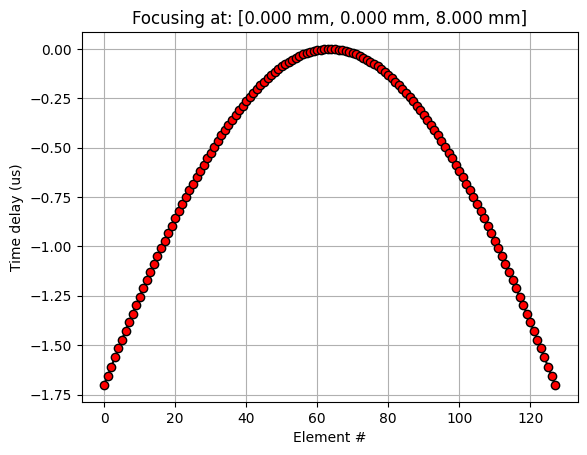

In [66]:
delays = domino.compute_delays(focus_mm = focus_mm, plot = True)

Focus: 0.000 mm, 0.000 mm, 8.000 mm


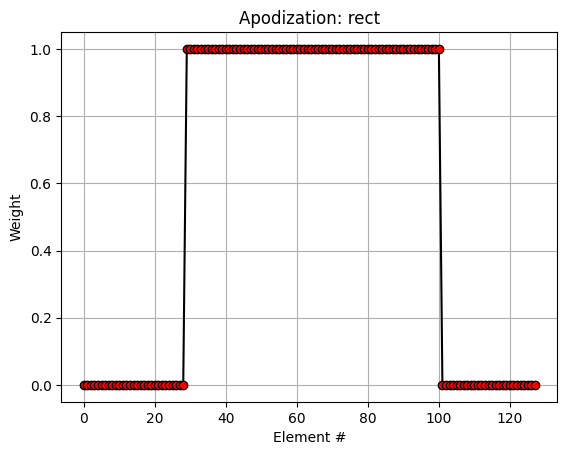

In [67]:
apodization = domino.compute_apodization(focus_mm = focus_mm, F_over_D = 1, apodization_type='rect', plot = True)

In [68]:
domino.set_apodization(apodization)
domino.set_delays(delays)
domino.show()

Widget(value='<iframe src="http://localhost:55689/index.html?ui=P_0x239f58c1fd0_2&reconnect=auto" class="pyvis…

## 4.1. Compute Pressure Field

In [69]:
import pysonogen
from pysonogen import pyfield

In [79]:
Domino_field = pyfield.PyField(domino)


Successfully initialized PyField with 
 LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=rect, tx_N_active=72, F_over_D=1)


In [87]:
field_info_mm = {
    "x_extent" : [-0.5, 0.5],
    "y_extent" : [-0.5, 0.5],
    "z_extent" : [7, 9],
    "dx" : 0.05,
    "dy" : 0.05,
    "dz" : 0.02,
}
pressure_field, x, y, z = Domino_field.compute_pressure_field(field_info_mm)


Creating simulation grid...
Computing spatial impulse response...
Computing all patch events...
Accumulating SIR from events...
Total computation time: 4.3636 seconds.
Computing pressure field...
Original h shape: (1024, 44541)
Reshaped h shape: (1024, 21, 21, 101)
Performing FFT...
Frequency searched: 12500000.0 Hz. Found: 12512218.963831866 Hz


Taking slice x_ind, y_ind, z_ind = 11/21, 11/21, 51/101


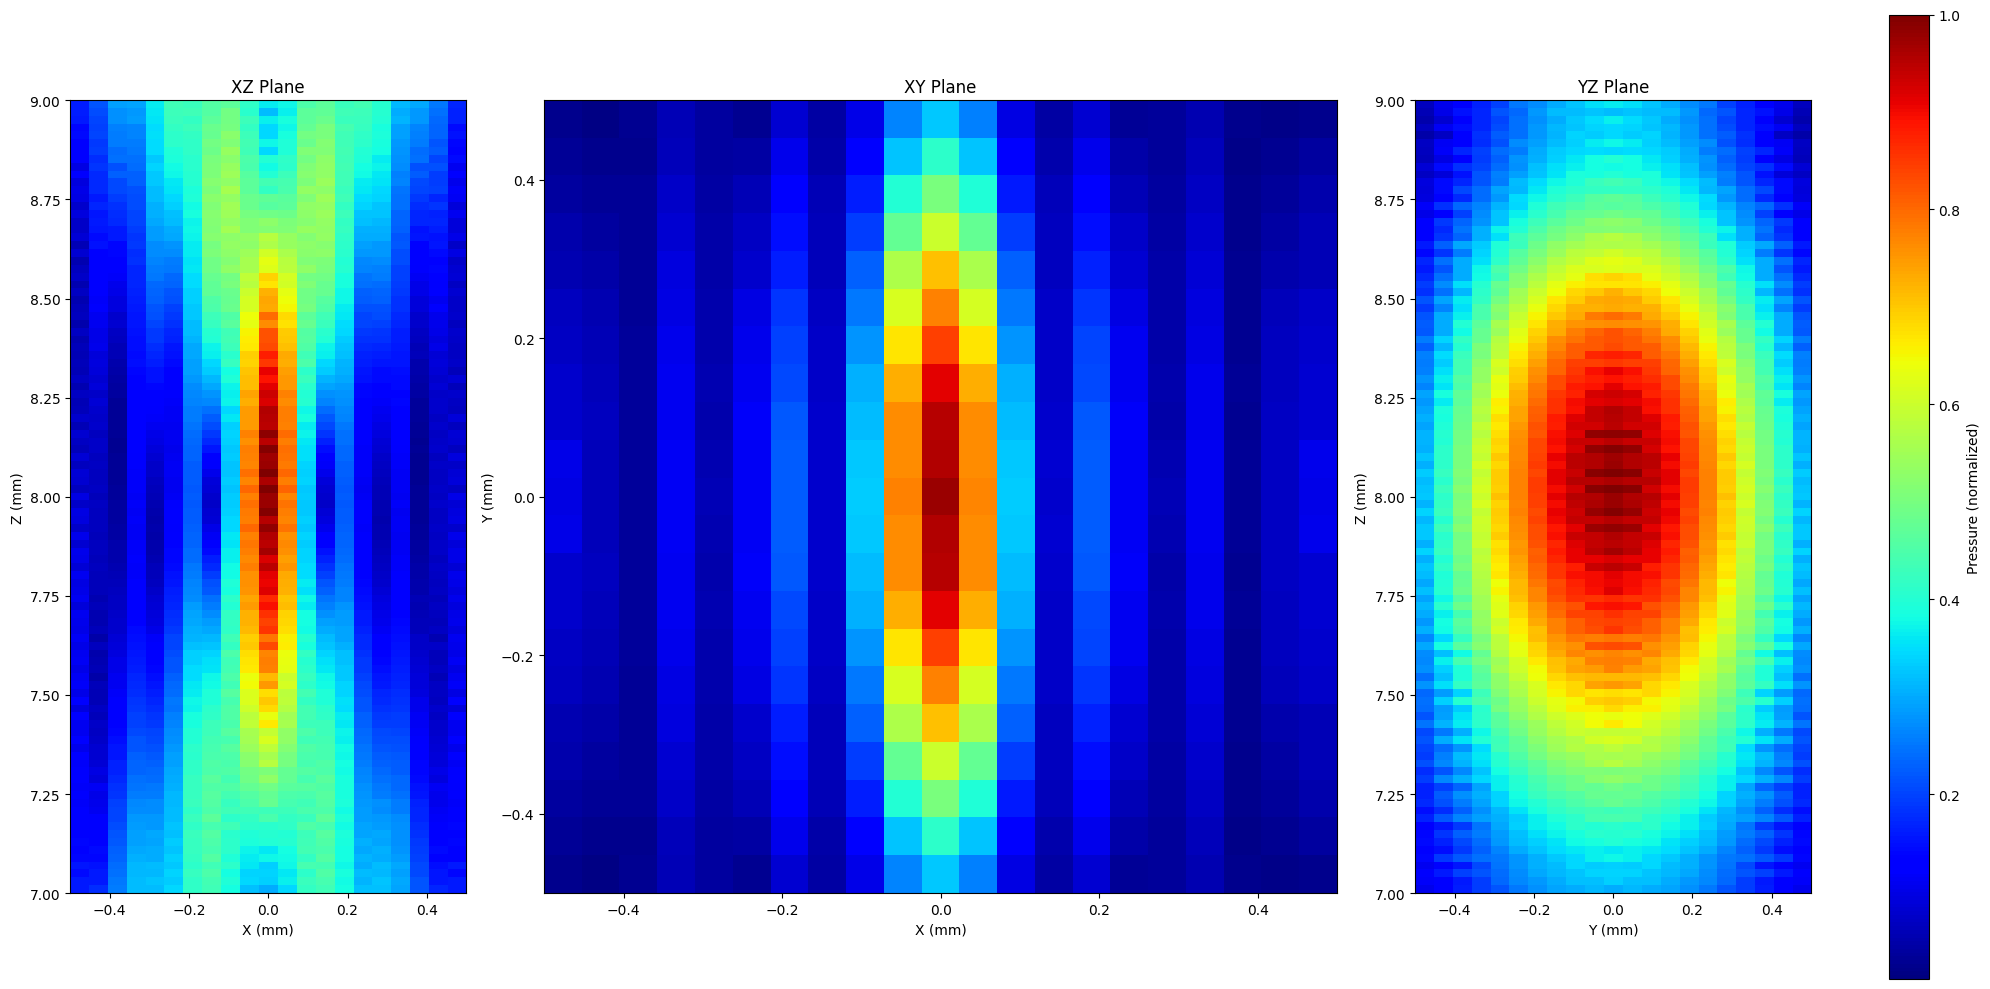

In [88]:
pysonogen.plot_field_planes(pressure_field,
                               x, y, z, figsize = (20, 10))

In [84]:
fft = np.fft.fft(pressure_field,axis = 2)


In [86]:
fft.shape

(21, 21, 201)

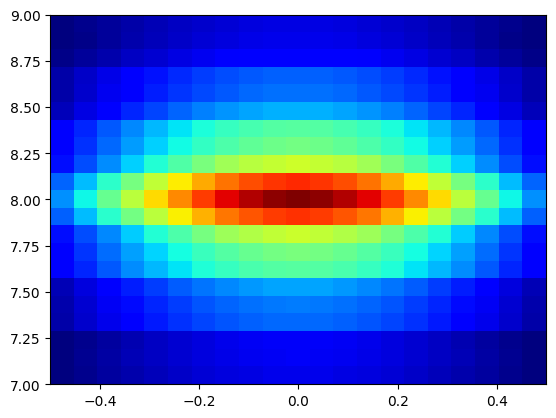

In [ ]:
plt.imshow(np.abs(fft[:,:,0]),)

One can use customized functions for visualization

In [82]:
import pysonogen

pysonogen.plot_pressure_field(pressure_field,
                               x, y, z, notebook = False)

### 4.1.3. Get 3D pressure field

In [ ]:
def create_pressure_volume(field_struct):
    """
    Create a 3D volume mesh from the pressure field data.

    Parameters:
    -----------
    field_struct : 
        Structured array containing the pressure field data.
        It should have fields 'x_vec', 'y_vec', 'z_vec', and 'scaled_half_field'.
    Returns:
    --------
    pv.PolyData
        PyVista PolyData object representing the pressure volume.
    """
    x,  y, z, pressure_field = compute_Pr_Field(field_struct)
    # If x, y, z are 1D (common case)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]

    nx, ny, nz = pressure_field.shape

    # Create the 3D UniformGrid
    pressure_vol = pv.ImageData(dimensions=(nx, ny, nz),
                        spacing=(dx, dy, dz),
                        origin=(x.min(), y.min(), z.min()))

    # Attach pressure data to the grid
    pressure_vol.point_data["Pressure"] = pressure_field.ravel(order="F")  # VERY important: Fortran order
    return pressure_vol

In [ ]:
region_bounds = pv_region2.bounds
# 1) We create the mesh for the transudcer and the pressure volume

# We create the mesh and flip it to match the coordinate system
# We originally flipped the z axis
TX_mesh = create_transducer_surface(TX_data, scaling_factor=1e3)#.flip_z(inplace=True) 
pressure_vol = create_pressure_volume(field_struct1)#.flip_z(inplace=True) 

# 2) We translate the mesh to the desired position

# We get the initial center of the mesh and the pressure volume
initial_TX_center = np.array(TX_mesh.center)
initial_pressure_center = np.array(pressure_vol.center)
print(f"TX : {TX_mesh.bounds} \n {TX_mesh.center}")
print(f"Pressure : {pressure_vol.bounds} \n {pressure_vol.center} \n ")

# We compute the new translation vector of the tranducer
d_btw_tx_brain = 3 # mm
x_tx = 0 # mm
z_tx = - d_btw_tx_brain + min(region_bounds[4], region_bounds[5]) # mm
y_tx = (region_bounds[3]+region_bounds[2])/2 # mm
translation_vector = np.array([x_tx, y_tx, z_tx]) 
print(f"Translation vector : {translation_vector} \n")

# We translate the mesh to the desired position
TX_mesh.translate(translation_vector, inplace=True) # Translate the mesh to the desired position
pressure_vol.translate(translation_vector, inplace=True)  # Translate the mesh to the desired position
center_tx = np.array(TX_mesh.center)
print(f"TX : {TX_mesh.bounds} \n {center_tx}")
print(f"Pressure : {pressure_vol.bounds} \n {pressure_vol.center}")

In [26]:
# Let's center all to the tx
pv_brain.translate(-center_tx, inplace=True)
pv_region.translate(-center_tx, inplace=True)
pv_region2.translate(-center_tx, inplace=True)
pressure_vol.translate(-center_tx, inplace=True)  # Translate the mesh to the desired position
TX_mesh.translate(-center_tx, inplace=True) # Translate the mesh to the desired position


PolyData (0x1b34d817700)
  N Cells:    1280
  N Points:   5120
  N Strips:   0
  X Bounds:   -7.039e+00, 7.039e+00
  Y Bounds:   -7.500e-01, 7.500e-01
  Z Bounds:   -1.762e-02, 1.762e-02
  N Arrays:   1

In [41]:

# 3. Plot in a standalone Qt window
plot_focal_spot = True

plotter = pv.Plotter(window_size=[1200, 800], title=f"Atlas + {region_name}", notebook=False) #,off_screen=True) # Need to add this parameter to save the screenshot

# 1) Add brain and regions meshes
plotter.add_mesh(pv_brain,   color="lightgrey", opacity=0.2,    label="Brain")
plotter.add_mesh(pv_region,  color="permanentgreen",     opacity=0.6,    label=region_name)
plotter.add_mesh(pv_region2,  color="cadmiumlemon",     opacity=0.6,    label=region_name2)

# 2) Add your TX_mesh with Apodization 
plotter.add_mesh(TX_mesh, 
    scalars="Apodization",     # use the attached scalar
    cmap="cool",             # color map (you can change to "plasma", "coolwarm", etc.)
    show_scalar_bar=True,
    scalar_bar_args={
        "title": "Apodization",
        "vertical": True,
        "title_font_size": 16,
        "label_font_size": 12,
        "position_x": 0.9,
        "position_y": 0.6,
        "height": 0.3,
    },
    label ="Transducer",  # label for the legend
    color = "purple", # color of the mesh
)

# 3) Add the pressure volume
if plot_focal_spot:
    # pick a threshold, e.g. halfway to the max
    threshold = 0.5 * pressure_field.max()
    iso_mesh = pressure_vol.contour([threshold], scalars="Pressure")  # Create isosurface at threshold# add that instead of (or in addition to) the volume
    plotter.add_mesh(
        iso_mesh,
        opacity=1.0,
        name="PressureIso",
        show_scalar_bar=False,
        label="Focal Spot",
        color = "r", # color of the mesh
    )
else:
    n_contours = 10
    min_val = 0
    max_val = pressure_field.max()
    levels = np.linspace(min_val, max_val, n_contours)
    iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")  # Create isosurface at threshold
    plotter.add_mesh(
        iso_mesh,
        scalars="Pressure",  # use the scalar to color surfaces
        cmap="jet",                   # color map
        opacity='linear',                  # solid surfaces
        show_scalar_bar=True,
        scalar_bar_args={"title": "Pressure",
            "vertical": True,
            "title_font_size": 16,
            "label_font_size": 12,
            "position_x": 0.9,
            "position_y": 0.2,
            "height": 0.3,
        },
        label="Pressure PII",
        color = "r", # color of the mesh
    )

plotter.add_axes()              # show XYZ axes
plotter.show_grid()             # show grid
# Force PyVista to recompute near/far clipping so nothing gets inadvertently cut
plotter.reset_camera_clipping_range()
plotter.add_legend(loc = 'upper left')   # show legend
plotter.camera.up = (0,0, -1)  # set the camera up vector to Z axis
plotter.camera_position = [(-28.698306158203337, 50.0637307486215, -12.962800638572176),
 (-0.9916999658255595, 4.286600862198689, 9.027294494271514),
 (0.2948778147587468, -0.26283246810551325, -0.9186763130029372)]

plotter.show()  # Add this parameter
# plotter.screenshot(f'RatBrainSonoGenat8mmFocalSpot{plot_focal_spot}.png')


In [42]:
plotter.camera_position

[(-20.204850578806113, 57.64176781329657, -2.4115399932513144),
 (-0.9916999658255595, 4.286600862198689, 9.027294494271514),
 (0.0723912778649082, -0.18408613403925303, -0.9802406837831044)]

In [43]:
import pyvista as pv
import numpy as np

# Toggle this to plot the focal spot
plot_focal_spot = True

# Create the plotter in off-screen mode for video
plotter = pv.Plotter(
    window_size=[1200, 800],
    title=f"Atlas + {region_name}",
    notebook=False,
    off_screen=True
)

plotter.set_background("white")

# 1) Add brain and region meshes
plotter.add_mesh(pv_brain, color="lightgrey", opacity=0.2, label="Brain")
plotter.add_mesh(pv_region, color="permanentgreen", opacity=0.6, label=region_name)
plotter.add_mesh(pv_region2, color="cadmiumlemon", opacity=0.6, label=region_name2)

# 2) Add TX_mesh with Apodization
plotter.add_mesh(
    TX_mesh,
    scalars="Apodization",
    cmap="cool",
    show_scalar_bar=True,
    scalar_bar_args={
        "title": "Apodization",
        "vertical": True,
        "title_font_size": 16,
        "label_font_size": 12,
        "position_x": 0.9,
        "position_y": 0.6,
        "height": 0.3,
    },
    label="Transducer",
    color="purple",
)

# 3) Add pressure field
if plot_focal_spot:
    threshold = 0.5 * pressure_field.max()
    iso_mesh = pressure_vol.contour([threshold], scalars="Pressure")
    plotter.add_mesh(
        iso_mesh,
        opacity=1.0,
        name="PressureIso",
        show_scalar_bar=False,
        label="Focal Spot",
        color="r",
    )
else:
    n_contours = 10
    levels = np.linspace(0, pressure_field.max(), n_contours)
    iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")
    plotter.add_mesh(
        iso_mesh,
        scalars="Pressure",
        cmap="jet",
        opacity='linear',
        show_scalar_bar=True,
        scalar_bar_args={
            "title": "Pressure",
            "vertical": True,
            "title_font_size": 16,
            "label_font_size": 12,
            "position_x": 0.9,
            "position_y": 0.2,
            "height": 0.3,
        },
        label="Pressure PII",
        color="r",
    )

# Additional visual elements
plotter.add_axes()
plotter.show_grid()
plotter.reset_camera_clipping_range()
plotter.add_legend(loc='upper left')
plotter.camera.up = (0, 0, -1)
plotter.camera_position = [(-20.204850578806113, 57.64176781329657, -2.4115399932513144),
 (-0.9916999658255595, 4.286600862198689, 9.027294494271514),
 (0.0723912778649082, -0.18408613403925303, -0.9802406837831044)]
# Render once before movie to apply camera and settings
plotter.render()

# Open movie file and define frame settings
n_frames = 180
video_filename = "brain_rotation.mp4"
plotter.open_movie(video_filename, framerate=20)

# Rotation loop
plotter.show(auto_close=False)
angle = 0 
for _ in range(n_frames):
    angle += 2  # Degrees to rotate per frame
    plotter.camera.azimuth = angle # Rotate camera
    plotter.render()
    plotter.write_frame()

# Finalize and save
plotter.close()
print(f" Video saved to: {video_filename}")


 Video saved to: brain_rotation.mp4


In [ ]:
import pyvista as pv
import numpy as np

# Toggle this to plot the focal spot
plot_focal_spot = True

# Create the plotter in off-screen mode for video
plotter = pv.Plotter(
    window_size=[1200, 800],
    title=f"Atlas + {region_name}",
    notebook=False,
    off_screen=True
)

plotter.set_background("white")

# 1) Add brain and region meshes
plotter.add_mesh(pv_brain, color="lightgrey", opacity=0.2, label="Brain")
plotter.add_mesh(pv_region, color="permanentgreen", opacity=0.6, label=region_name)
plotter.add_mesh(pv_region2, color="cadmiumlemon", opacity=0.6, label=region_name2)

# 2) Add TX_mesh with Apodization
plotter.add_mesh(
    TX_mesh,
    scalars="Apodization",
    cmap="cool",
    show_scalar_bar=True,
    scalar_bar_args={
        "title": "Apodization",
        "vertical": True,
        "title_font_size": 16,
        "label_font_size": 12,
        "position_x": 0.9,
        "position_y": 0.6,
        "height": 0.3,
    },
    label="Transducer",
    color="purple",
)

# 3) Add pressure field
if plot_focal_spot:
    threshold = 0.5 * pressure_field.max()
    iso_mesh = pressure_vol.contour([threshold], scalars="Pressure")
    plotter.add_mesh(
        iso_mesh,
        opacity=1.0,
        name="PressureIso",
        show_scalar_bar=False,
        label="Focal Spot",
        color="r",
    )
else:
    n_contours = 10
    levels = np.linspace(0, pressure_field.max(), n_contours)
    iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")
    plotter.add_mesh(
        iso_mesh,
        scalars="Pressure",
        cmap="jet",
        opacity='linear',
        show_scalar_bar=True,
        scalar_bar_args={
            "title": "Pressure",
            "vertical": True,
            "title_font_size": 16,
            "label_font_size": 12,
            "position_x": 0.9,
            "position_y": 0.2,
            "height": 0.3,
        },
        label="Pressure PII",
        color="r",
    )

# Additional visual elements
plotter.add_axes()
plotter.show_grid()
plotter.reset_camera_clipping_range()
plotter.add_legend(loc='upper left')
plotter.camera.up = (0, 0, -1)
# plotter.camera_position = [
#     (-28.698306158203337, 50.0637307486215, -12.962800638572176),
#     (-0.9916999658255595, 4.286600862198689, 9.027294494271514),
#     (0.2948778147587468, -0.26283246810551325, -0.9186763130029372)
# ]

# Render once before movie to apply camera and settings
plotter.render()

# Open movie file and define frame settings
n_frames = 180
video_filename = "brain_rotation.mp4"
plotter.open_movie(video_filename, framerate=20)

# Rotation loop
plotter.show(auto_close=False)
angle = 0 
for _ in range(n_frames):
    angle += 2  # Degrees to rotate per frame
    plotter.camera.azimuth = angle # Rotate camera
    plotter.render()
    plotter.write_frame()

# Finalize and save
plotter.close()
print(f" Video saved to: {video_filename}")


 Video saved to: brain_rotation.mp4
